# Simple End-to-End Machine Learning Projects

This notebook guides you through the complete workflow for building machine learning projects from data acquisition to model deployment, with two practical examples:
1. Housing Price Prediction (Regression)
2. Customer Churn Prediction (Classification)

Each section covers essential steps that can be applied to various ML projects.

## 1. Import Required Libraries

First, we'll import all the necessary libraries for our machine learning workflow:

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, r2_score, 
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Algorithms
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC

# Model persistence
import joblib
import pickle

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Data Acquisition and Exploration

In this section, we'll learn how to load datasets, perform initial exploratory data analysis (EDA), and visualize key features to understand our data.

### 2.1 Loading Data

In [2]:
# Example: Loading housing dataset for regression task
from sklearn.datasets import fetch_california_housing

# Load California housing dataset
housing_data = fetch_california_housing()
housing_df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
housing_df['PRICE'] = housing_data.target

# Display first few rows
print("Housing Dataset Preview:")
display(housing_df.head())

# Example: Loading customer data for classification task
from sklearn.datasets import load_breast_cancer

# We'll use breast cancer dataset as a proxy for customer churn
# (1 = retained customer, 0 = churned customer in our analogy)
customer_data = load_breast_cancer()
customer_df = pd.DataFrame(customer_data.data, columns=customer_data.feature_names)
customer_df['CHURN'] = customer_data.target

# Display first few rows
print("\nCustomer Churn Dataset Preview:")
display(customer_df.head())

Housing Dataset Preview:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Customer Churn Dataset Preview:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,CHURN
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2.2 Exploratory Data Analysis (EDA)

Let's explore our datasets to understand their structure, identify patterns, and detect potential issues.

In [3]:
# Basic statistics for housing dataset
print("Housing Dataset Summary Statistics:")
display(housing_df.describe())

# Check for missing values
print("\nMissing values in Housing Dataset:")
display(housing_df.isnull().sum())

# Data types
print("\nData Types in Housing Dataset:")
display(housing_df.dtypes)

# Similar analysis for customer dataset
print("\nCustomer Dataset Summary Statistics:")
display(customer_df.describe())

print("\nMissing values in Customer Dataset:")
display(customer_df.isnull().sum())

print("\nData Types in Customer Dataset:")
display(customer_df.dtypes)

# Class distribution for classification problem
print("\nCustomer Churn Distribution:")
display(customer_df['CHURN'].value_counts(normalize=True) * 100)

Housing Dataset Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Missing values in Housing Dataset:


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


Data Types in Housing Dataset:


...

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
CHURN                      0
dtype: int64


Data Types in Customer Dataset:


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      


Customer Churn Distribution:


CHURN
1    62.741652
0    37.258348
Name: proportion, dtype: float64

### 2.3 Data Visualization

Visualizing the data helps us understand distributions, correlations, and relationships between features.

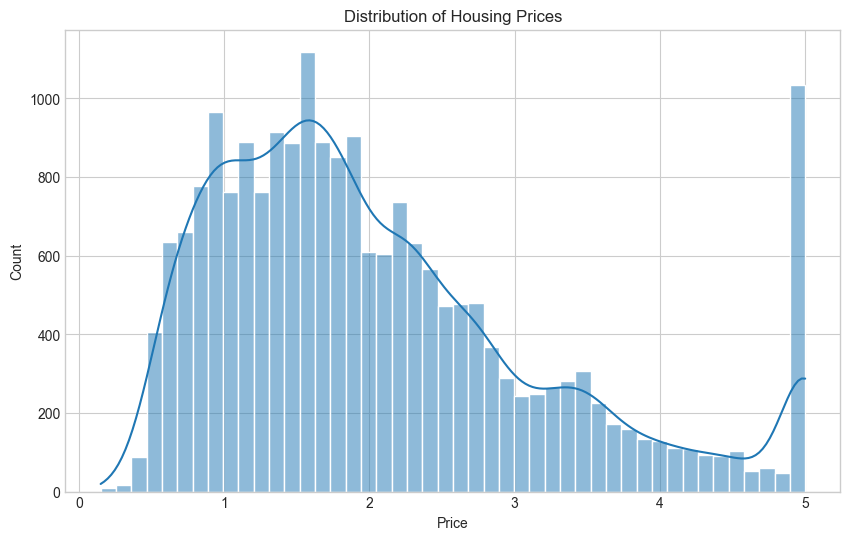

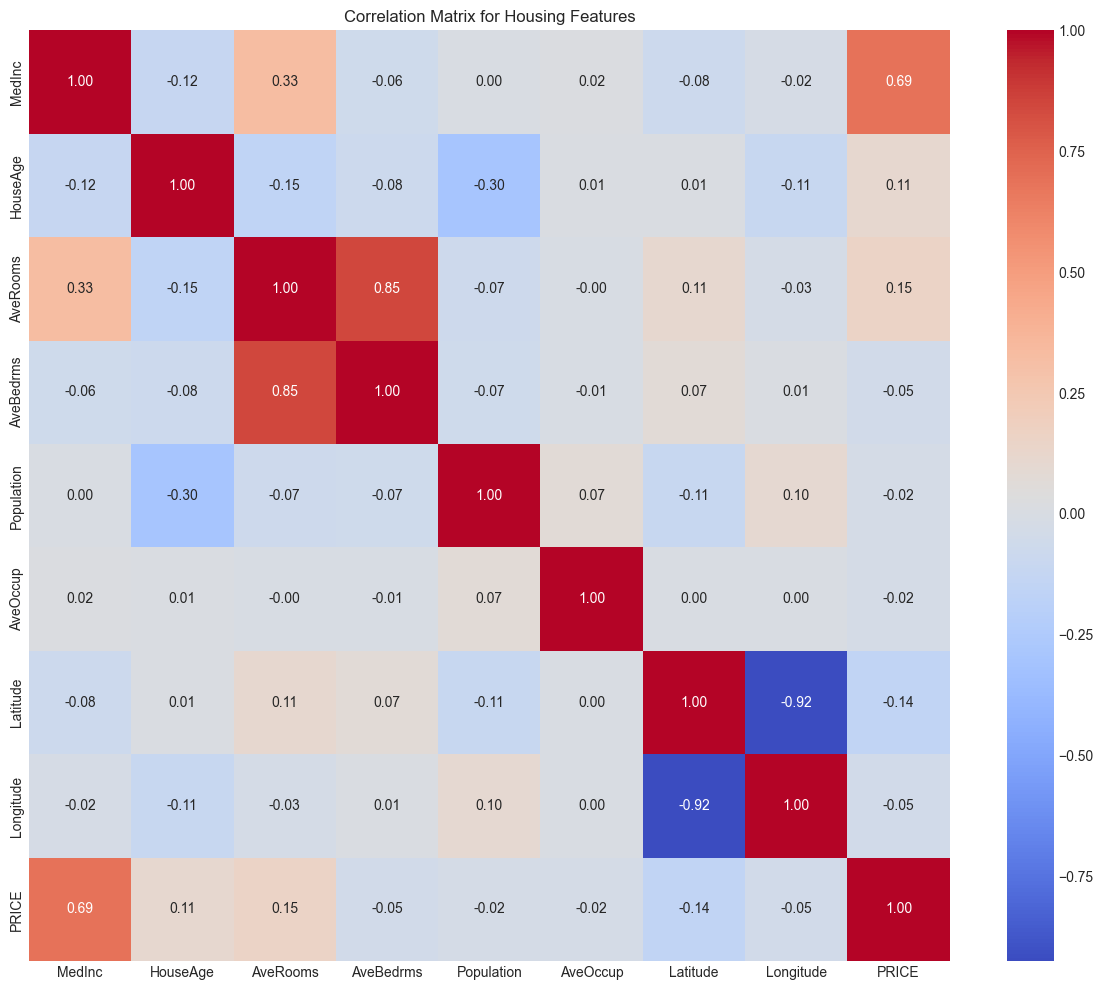

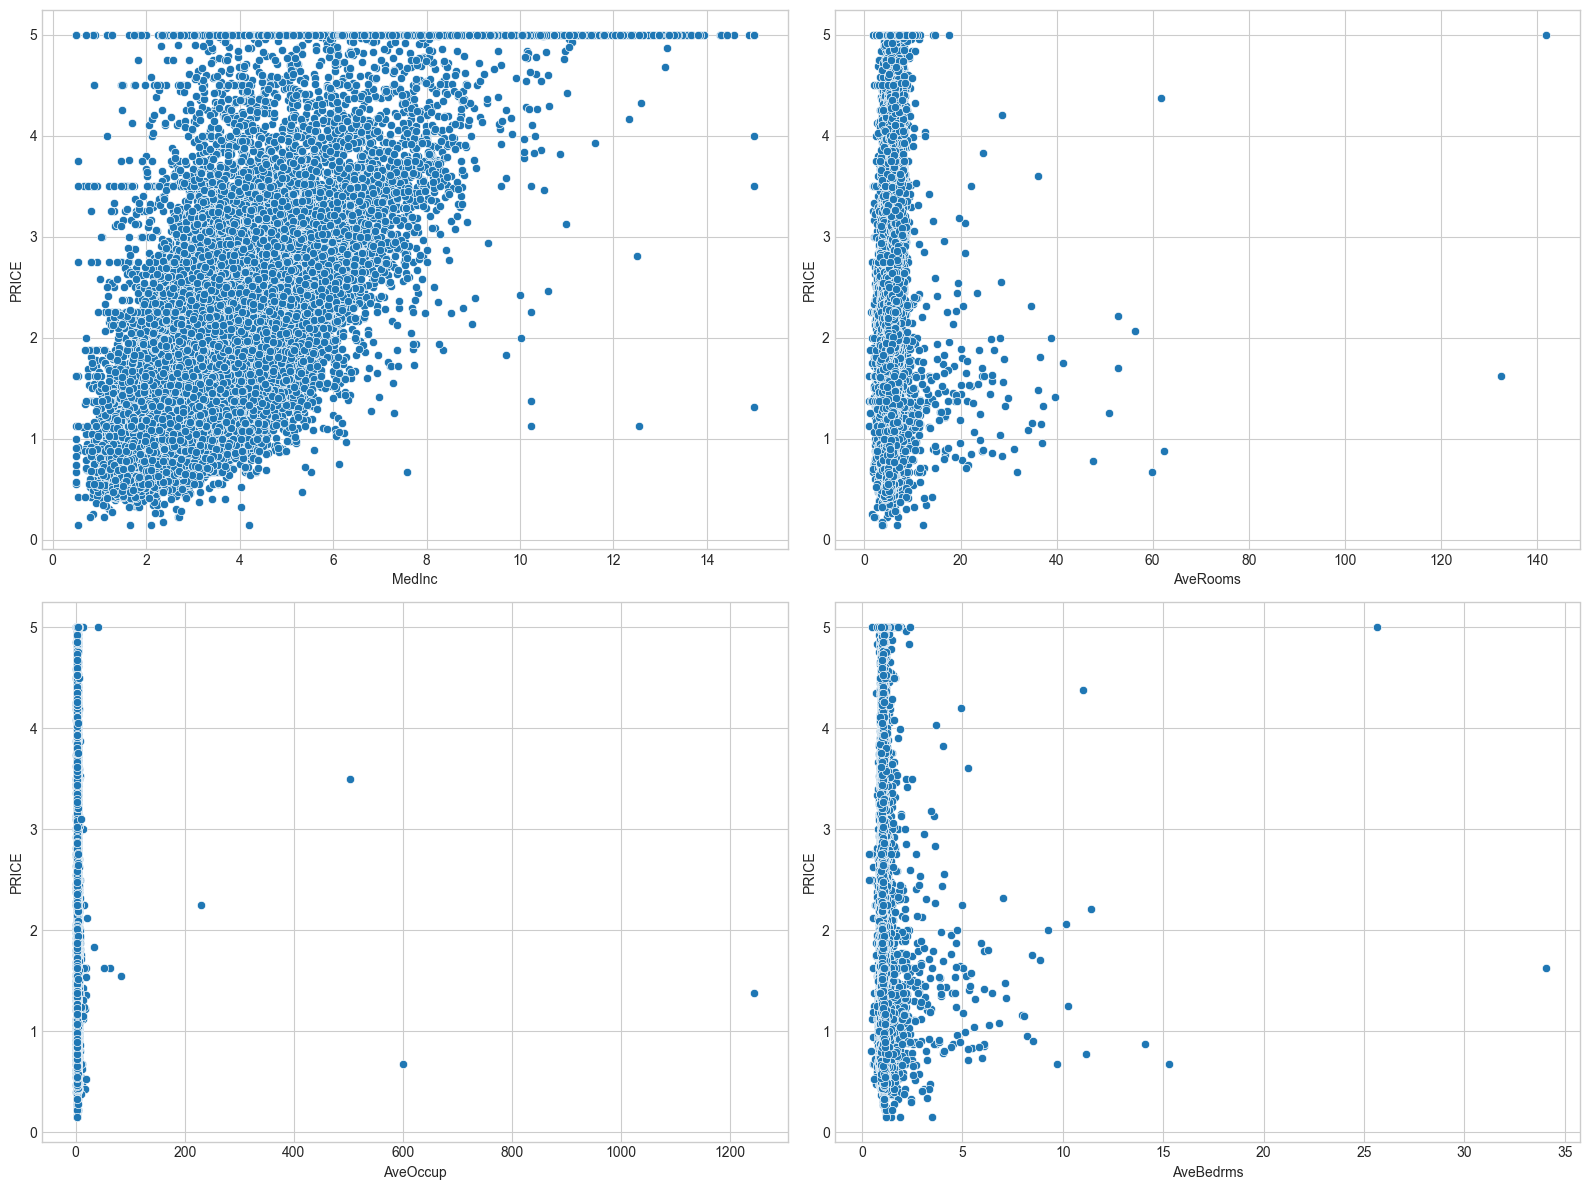

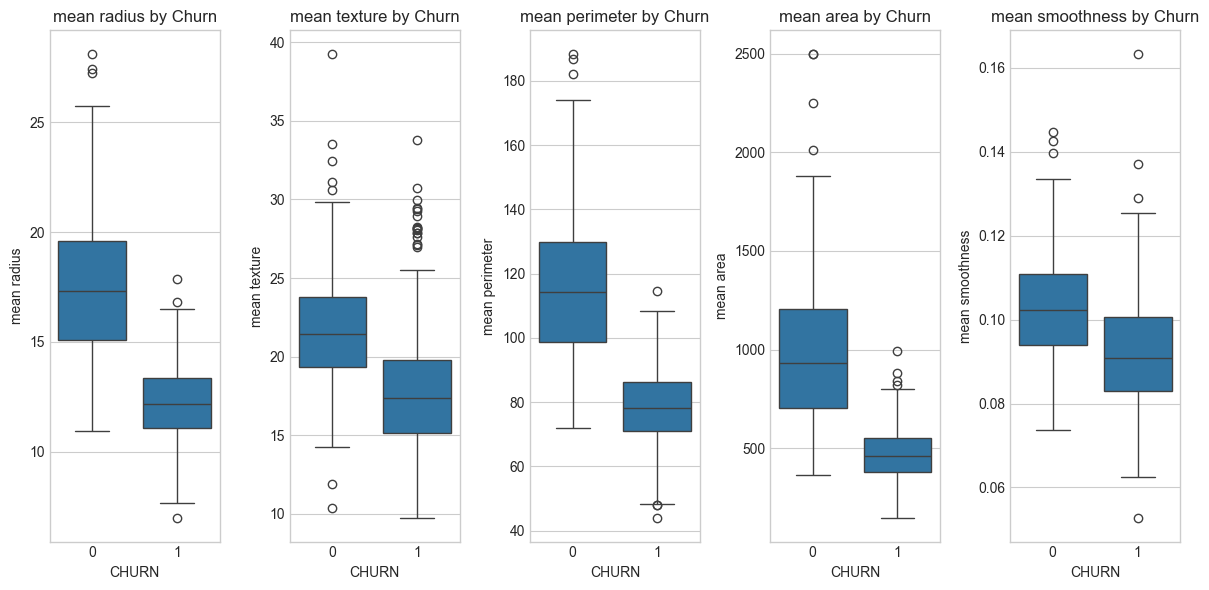

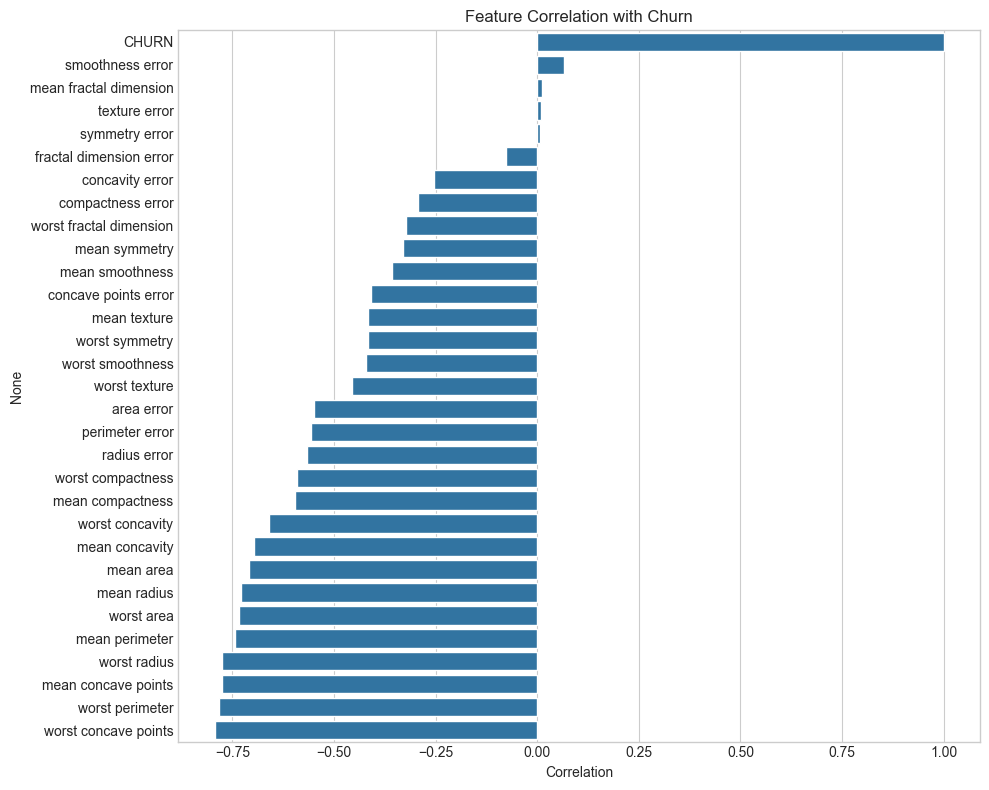

<Figure size 1400x1000 with 0 Axes>

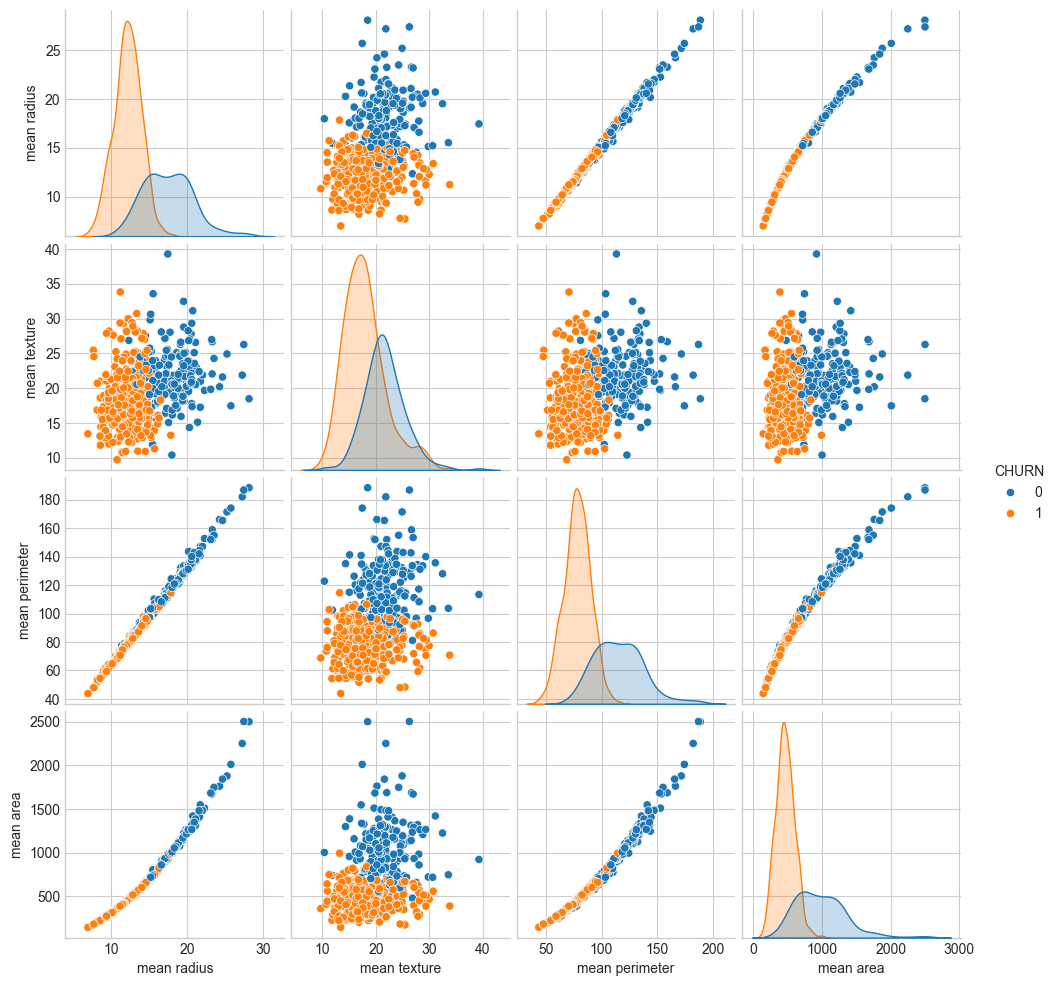

In [4]:
# ---- Housing Dataset Visualizations ----

# 1. Distribution of housing prices
plt.figure(figsize=(10, 6))
sns.histplot(housing_df['PRICE'], kde=True)
plt.title('Distribution of Housing Prices')
plt.xlabel('Price')
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(housing_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Housing Features')
plt.tight_layout()
plt.show()

# 3. Scatter plot of selected features vs price
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.scatterplot(x='MedInc', y='PRICE', data=housing_df, ax=axes[0, 0])
sns.scatterplot(x='AveRooms', y='PRICE', data=housing_df, ax=axes[0, 1])
sns.scatterplot(x='AveOccup', y='PRICE', data=housing_df, ax=axes[1, 0])
sns.scatterplot(x='AveBedrms', y='PRICE', data=housing_df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

# ---- Customer Churn Dataset Visualizations ----

# 1. Feature distributions by churn status
plt.figure(figsize=(12, 6))
features_to_plot = customer_df.columns[:5]  # Select first 5 features for brevity
for i, feature in enumerate(features_to_plot):
    plt.subplot(1, 5, i+1)
    sns.boxplot(x='CHURN', y=feature, data=customer_df)
    plt.title(f'{feature} by Churn')
plt.tight_layout()
plt.show()

# 2. Correlation with churn
correlations = customer_df.corr()['CHURN'].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(y=correlations.index, x=correlations.values)
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# 3. Pair plot for selected features
plt.figure(figsize=(14, 10))
selected_features = list(customer_df.columns[:4]) + ['CHURN']
sns.pairplot(customer_df[selected_features], hue='CHURN')
plt.show()

## 3. Data Preprocessing and Feature Engineering

Before training models, we need to prepare our data by handling missing values, encoding categorical features, scaling numerical features, and potentially creating new features.

In [5]:
# ---- Housing Data Preprocessing ----

# Split housing data into features and target
X_housing = housing_df.drop('PRICE', axis=1)
y_housing = housing_df['PRICE']

# Split into training and testing sets
X_housing_train, X_housing_test, y_housing_train, y_housing_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Create preprocessing pipeline
housing_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit and transform training data
X_housing_train_processed = housing_preprocessor.fit_transform(X_housing_train)
X_housing_test_processed = housing_preprocessor.transform(X_housing_test)

print("Housing data preprocessing complete.")
print(f"Processed training data shape: {X_housing_train_processed.shape}")
print(f"Processed testing data shape: {X_housing_test_processed.shape}")

# ---- Customer Churn Data Preprocessing ----

# Split churn data into features and target
X_customer = customer_df.drop('CHURN', axis=1)
y_customer = customer_df['CHURN']

# Split into training and testing sets
X_customer_train, X_customer_test, y_customer_train, y_customer_test = train_test_split(
    X_customer, y_customer, test_size=0.2, random_state=42, stratify=y_customer
)

# Create preprocessing pipeline
customer_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit and transform training data
X_customer_train_processed = customer_preprocessor.fit_transform(X_customer_train)
X_customer_test_processed = customer_preprocessor.transform(X_customer_test)

print("\nCustomer data preprocessing complete.")
print(f"Processed training data shape: {X_customer_train_processed.shape}")
print(f"Processed testing data shape: {X_customer_test_processed.shape}")

Housing data preprocessing complete.
Processed training data shape: (16512, 8)
Processed testing data shape: (4128, 8)

Customer data preprocessing complete.
Processed training data shape: (455, 30)
Processed testing data shape: (114, 30)


### 3.1 Feature Engineering - Creating New Features

Feature engineering is the process of creating new features that could improve model performance.

In [9]:
# # ---- Housing Feature Engineering ----

# # Create a copy to avoid modifying the original data
# housing_df_engineered = housing_df.copy()

# # Create new features
# housing_df_engineered['BEDROOM_RATIO'] = housing_df['AveBedrms'] / housing_df['AveRooms']
# housing_df_engineered['ROOMS_PER_HOUSEHOLD'] = housing_df['AveRooms'] / housing_df['AveOccup']
# housing_df_engineered['POPULATION_PER_HOUSEHOLD'] = housing_df['Population'] / housing_df['Households']
# housing_df_engineered['INCOME_PER_ROOM'] = housing_df['MedInc'] / housing_df['AveRooms']

# # Display the new features
# print("Housing dataset with engineered features:")
# display(housing_df_engineered.head())

# # Check correlation of engineered features with target
# corr_with_price = housing_df_engineered.corr()['PRICE'].sort_values(ascending=False)
# print("\nCorrelation of features with housing price:")
# display(corr_with_price)

# # ---- Customer Churn Feature Engineering ----
# # For demonstration purposes, let's create some polynomial features

# from sklearn.preprocessing import PolynomialFeatures

# # Create polynomial features from original features
# poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
# X_customer_poly = poly.fit_transform(X_customer.iloc[:, :5])  # Using first 5 features for brevity

# # Create a new DataFrame with the polynomial features
# feature_names = poly.get_feature_names_out(X_customer.columns[:5])
# customer_df_poly = pd.DataFrame(X_customer_poly, columns=feature_names)

# print("\nPolynomial features for customer data:")
# display(customer_df_poly.head())

```
KeyError: 'Households'
```

In [10]:
# ---- Housing Feature Engineering ----

from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# Load California housing dataset
housing_data = fetch_california_housing()
housing_df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
housing_df['PRICE'] = housing_data.target

# Display dataset preview
print("Housing Dataset Preview:")
display(housing_df.head())

# Create a copy to avoid modifying the original data
housing_df_engineered = housing_df.copy()

# Create new engineered features
housing_df_engineered['BEDROOM_RATIO'] = housing_df['AveBedrms'] / housing_df['AveRooms']
housing_df_engineered['ROOMS_PER_HOUSEHOLD'] = housing_df['AveRooms'] / housing_df['AveOccup']
housing_df_engineered['POPULATION_PER_HOUSEHOLD'] = housing_df['Population'] / housing_df['AveOccup']  # Approximation
housing_df_engineered['INCOME_PER_ROOM'] = housing_df['MedInc'] / housing_df['AveRooms']

# Display the new features
print("\nHousing dataset with engineered features:")
display(housing_df_engineered.head())

# Correlation with price
corr_with_price = housing_df_engineered.corr()['PRICE'].sort_values(ascending=False)
print("\nCorrelation of features with housing price:")
display(corr_with_price)

# ---- Customer Churn Feature Engineering ----

# Load breast cancer dataset as proxy for customer churn
from sklearn.datasets import load_breast_cancer

customer_data = load_breast_cancer()
customer_df = pd.DataFrame(customer_data.data, columns=customer_data.feature_names)
customer_df['CHURN'] = customer_data.target

# Display customer dataset preview
print("\nCustomer Churn Dataset Preview:")
display(customer_df.head())

# Polynomial features on first 5 columns (for brevity)
X_customer = customer_df.drop(columns='CHURN')
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_customer_poly = poly.fit_transform(X_customer.iloc[:, :5])

# Create a DataFrame with the polynomial features
feature_names = poly.get_feature_names_out(X_customer.columns[:5])
customer_df_poly = pd.DataFrame(X_customer_poly, columns=feature_names)

print("\nPolynomial features for customer data:")
display(customer_df_poly.head())

Housing Dataset Preview:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Housing dataset with engineered features:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE,BEDROOM_RATIO,ROOMS_PER_HOUSEHOLD,POPULATION_PER_HOUSEHOLD,INCOME_PER_ROOM
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.146591,2.732919,126.0,1.192017
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.155797,2.956685,1138.0,1.330750
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.129516,2.957661,177.0,0.875637
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.184458,2.283154,219.0,0.970046
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.172096,2.879646,259.0,0.612272



Correlation of features with housing price:


PRICE                       1.000000
MedInc                      0.688075
INCOME_PER_ROOM             0.665274
ROOMS_PER_HOUSEHOLD         0.209482
AveRooms                    0.151948
HouseAge                    0.105623
POPULATION_PER_HOUSEHOLD    0.065843
AveOccup                   -0.023737
Population                 -0.024650
Longitude                  -0.045967
AveBedrms                  -0.046701
Latitude                   -0.144160
BEDROOM_RATIO              -0.255624
Name: PRICE, dtype: float64


Customer Churn Dataset Preview:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,CHURN
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Polynomial features for customer data:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean radius mean texture,mean radius mean perimeter,mean radius mean area,mean radius mean smoothness,mean texture mean perimeter,mean texture mean area,mean texture mean smoothness,mean perimeter mean area,mean perimeter mean smoothness,mean area mean smoothness
0,17.99,10.38,122.80,1001.0,0.11840,186.7362,2209.1720,18007.990,2.130016,1274.6640,10390.380,1.228992,122922.800,14.539520,118.51840
1,20.57,17.77,132.90,1326.0,0.08474,365.5289,2733.7530,27275.820,1.743102,2361.6330,23563.020,1.505830,176225.400,11.261946,112.36524
2,19.69,21.25,130.00,1203.0,0.10960,418.4125,2559.7000,23687.070,2.158024,2762.5000,25563.750,2.329000,156390.000,14.248000,131.84880
3,11.42,20.38,77.58,386.1,0.14250,232.7396,885.9636,4409.262,1.627350,1581.0804,7868.718,2.904150,29953.638,11.055150,55.01925
4,20.29,14.34,135.10,1297.0,0.10030,290.9586,2741.1790,26316.130,2.035087,1937.3340,18598.980,1.438302,175224.700,13.550530,130.08910


## 4. Model Selection and Training

In this section, we'll train different models on our datasets and compare their performance.

In [11]:
# ---- Housing Price Prediction Models (Regression) ----

# Initialize regression models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

# Train and evaluate regression models
for name, model in regression_models.items():
    # Train the model
    model.fit(X_housing_train_processed, y_housing_train)
    
    # Make predictions
    y_pred = model.predict(X_housing_test_processed)
    
    # Evaluate the model
    mse = mean_squared_error(y_housing_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_housing_test, y_pred)
    
    print(f"\n{name} Performance:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# ---- Customer Churn Prediction Models (Classification) ----

# Initialize classification models
classification_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate classification models
for name, model in classification_models.items():
    # Train the model
    model.fit(X_customer_train_processed, y_customer_train)
    
    # Make predictions
    y_pred = model.predict(X_customer_test_processed)
    
    # Evaluate the model
    accuracy = accuracy_score(y_customer_test, y_pred)
    precision = precision_score(y_customer_test, y_pred)
    recall = recall_score(y_customer_test, y_pred)
    f1 = f1_score(y_customer_test, y_pred)
    
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")


Linear Regression Performance:
Mean Squared Error: 0.5559
Root Mean Squared Error: 0.7456
R² Score: 0.5758

Decision Tree Performance:
Mean Squared Error: 0.4940
Root Mean Squared Error: 0.7028
R² Score: 0.6230

Random Forest Performance:
Mean Squared Error: 0.2552
Root Mean Squared Error: 0.5051
R² Score: 0.8053

Logistic Regression Performance:
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861

Decision Tree Performance:
Accuracy: 0.9123
Precision: 0.9559
Recall: 0.9028
F1 Score: 0.9286

Random Forest Performance:
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1 Score: 0.9655


### 4.1 Hyperparameter Tuning

Let's improve our models by tuning their hyperparameters using GridSearchCV.

### RUN ON MAC

In [ ]:
# ---- Hyperparameter Tuning for Housing Price Prediction ----

# Define parameter grid for Random Forest Regressor
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Create GridSearchCV object
rf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV
print("Performing grid search for housing price prediction model...")
rf_grid_search.fit(X_housing_train_processed, y_housing_train)

# Best parameters and score
print(f"\nBest parameters: {rf_grid_search.best_params_}")
print(f"Best RMSE: {np.sqrt(-rf_grid_search.best_score_):.4f}")

# Evaluate best model on test set
best_rf_regressor = rf_grid_search.best_estimator_
y_pred_rf = best_rf_regressor.predict(X_housing_test_processed)
rf_mse = mean_squared_error(y_housing_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_housing_test, y_pred_rf)

print(f"\nBest Random Forest on test set:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R² Score: {rf_r2:.4f}")

# ---- Hyperparameter Tuning for Customer Churn Prediction ----

# Define parameter grid for Random Forest Classifier
rfc_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

# Create GridSearchCV object
rfc_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rfc_param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV
print("\nPerforming grid search for customer churn prediction model...")
rfc_grid_search.fit(X_customer_train_processed, y_customer_train)

# Best parameters and score
print(f"\nBest parameters: {rfc_grid_search.best_params_}")
print(f"Best F1 Score: {rfc_grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_rf_classifier = rfc_grid_search.best_estimator_
y_pred_rfc = best_rf_classifier.predict(X_customer_test_processed)
rfc_accuracy = accuracy_score(y_customer_test, y_pred_rfc)
rfc_precision = precision_score(y_customer_test, y_pred_rfc)
rfc_recall = recall_score(y_customer_test, y_pred_rfc)
rfc_f1 = f1_score(y_customer_test, y_pred_rfc)

print(f"\nBest Random Forest Classifier on test set:")
print(f"Accuracy: {rfc_accuracy:.4f}")
print(f"Precision: {rfc_precision:.4f}")
print(f"Recall: {rfc_recall:.4f}")
print(f"F1 Score: {rfc_f1:.4f}")

## 5. Model Evaluation

Let's evaluate our models in more detail using appropriate metrics and visualization techniques.

### RUN ON MAC

In [ ]:
# ---- Evaluate Housing Price Prediction Models ----

# Compare actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_housing_test, y_pred_rf, alpha=0.5)
plt.plot([y_housing_test.min(), y_housing_test.max()], 
         [y_housing_test.min(), y_housing_test.max()], 
         'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Random Forest: Actual vs Predicted Housing Prices')
plt.show()

# Residual plot
residuals = y_housing_test - y_pred_rf
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Random Forest: Residual Plot')
plt.show()

# Feature importance
feature_importances = pd.Series(
    best_rf_regressor.feature_importances_,
    index=housing_df.drop('PRICE', axis=1).columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Random Forest: Feature Importances for Housing Price Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# ---- Evaluate Customer Churn Prediction Models ----

# Confusion matrix
cm = confusion_matrix(y_customer_test, y_pred_rfc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Churned', 'Retained'], 
            yticklabels=['Churned', 'Retained'])
plt.title('Random Forest: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_customer_test, y_pred_rfc, 
                           target_names=['Churned', 'Retained']))

# ROC curve and AUC
y_prob_rfc = best_rf_classifier.predict_proba(X_customer_test_processed)[:, 1]
fpr, tpr, _ = roc_curve(y_customer_test, y_prob_rfc)
auc = roc_auc_score(y_customer_test, y_prob_rfc)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Customer Churn Prediction')
plt.legend()
plt.show()

# Feature importance
feature_importances_clf = pd.Series(
    best_rf_classifier.feature_importances_,
    index=customer_df.drop('CHURN', axis=1).columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances_clf.values[:10], y=feature_importances_clf.index[:10])
plt.title('Random Forest: Top 10 Feature Importances for Customer Churn Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 5.1 Cross-Validation for More Robust Evaluation

Let's use cross-validation to get a more reliable estimate of our models' performance.

### RUN ON MAC

In [ ]:
# ---- Cross-Validation for Housing Price Prediction ----
from sklearn.model_selection import KFold

# Create KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation for Random Forest Regressor
cv_scores_rmse = -cross_val_score(
    best_rf_regressor, 
    X_housing_train_processed, 
    y_housing_train,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

cv_scores_r2 = cross_val_score(
    best_rf_regressor, 
    X_housing_train_processed, 
    y_housing_train,
    cv=kf,
    scoring='r2'
)

print("Housing Price Prediction - 5-Fold Cross-Validation Results:")
print(f"RMSE: {cv_scores_rmse.mean():.4f} (±{cv_scores_rmse.std():.4f})")
print(f"R²: {cv_scores_r2.mean():.4f} (±{cv_scores_r2.std():.4f})")

# ---- Cross-Validation for Customer Churn Prediction ----
from sklearn.model_selection import StratifiedKFold

# Create StratifiedKFold cross-validator
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation for Random Forest Classifier
cv_scores_accuracy = cross_val_score(
    best_rf_classifier, 
    X_customer_train_processed, 
    y_customer_train,
    cv=skf,
    scoring='accuracy'
)

cv_scores_f1 = cross_val_score(
    best_rf_classifier, 
    X_customer_train_processed, 
    y_customer_train,
    cv=skf,
    scoring='f1'
)

print("\nCustomer Churn Prediction - 5-Fold Cross-Validation Results:")
print(f"Accuracy: {cv_scores_accuracy.mean():.4f} (±{cv_scores_accuracy.std():.4f})")
print(f"F1 Score: {cv_scores_f1.mean():.4f} (±{cv_scores_f1.std():.4f})")

## 6. Model Deployment

Once we're satisfied with our models, we need to save them for future use and create functions for making predictions on new data.

### RUN ON MAC

In [ ]:
# ---- Save Housing Price Prediction Model ----
import os

# Create a directory for saving models if it doesn't exist
model_dir = "models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the model and preprocessor
housing_model_path = os.path.join(model_dir, "housing_price_model.joblib")
joblib.dump(best_rf_regressor, housing_model_path)

housing_preprocessor_path = os.path.join(model_dir, "housing_preprocessor.joblib")
joblib.dump(housing_preprocessor, housing_preprocessor_path)

print(f"Housing price prediction model saved to {housing_model_path}")
print(f"Housing preprocessor saved to {housing_preprocessor_path}")

# ---- Save Customer Churn Prediction Model ----
customer_model_path = os.path.join(model_dir, "customer_churn_model.joblib")
joblib.dump(best_rf_classifier, customer_model_path)

customer_preprocessor_path = os.path.join(model_dir, "customer_preprocessor.joblib")
joblib.dump(customer_preprocessor, customer_preprocessor_path)

print(f"Customer churn prediction model saved to {customer_model_path}")
print(f"Customer preprocessor saved to {customer_preprocessor_path}")

# ---- Functions for Making Predictions on New Data ----

def predict_housing_price(new_data, model_path=housing_model_path, preprocessor_path=housing_preprocessor_path):
    """
    Make housing price predictions on new data.
    
    Parameters:
    -----------
    new_data : DataFrame
        New data with the same features as the training data
    model_path : str
        Path to the saved model
    preprocessor_path : str
        Path to the saved preprocessor
        
    Returns:
    --------
    numpy.ndarray
        Predicted housing prices
    """
    # Load model and preprocessor
    model = joblib.load(model_path)
    preprocessor = joblib.load(preprocessor_path)
    
    # Preprocess the new data
    X_new_processed = preprocessor.transform(new_data)
    
    # Make predictions
    predictions = model.predict(X_new_processed)
    
    return predictions

def predict_customer_churn(new_data, model_path=customer_model_path, preprocessor_path=customer_preprocessor_path):
    """
    Predict customer churn probability on new data.
    
    Parameters:
    -----------
    new_data : DataFrame
        New data with the same features as the training data
    model_path : str
        Path to the saved model
    preprocessor_path : str
        Path to the saved preprocessor
        
    Returns:
    --------
    tuple
        (churn_predictions, churn_probabilities)
    """
    # Load model and preprocessor
    model = joblib.load(model_path)
    preprocessor = joblib.load(preprocessor_path)
    
    # Preprocess the new data
    X_new_processed = preprocessor.transform(new_data)
    
    # Make predictions
    predictions = model.predict(X_new_processed)
    probabilities = model.predict_proba(X_new_processed)[:, 1]
    
    return predictions, probabilities

### 6.1 Demo: Using the Deployed Models

Let's demonstrate how to use our deployed models to make predictions on new data.

### RUN ON MAC

In [ ]:
# ---- Demo: Using Housing Price Prediction Model ----

# Create sample new housing data
new_housing_data = pd.DataFrame({
    'MedInc': [8.5, 3.2, 5.0],
    'HouseAge': [25.0, 15.0, 30.0],
    'AveRooms': [6.0, 4.5, 7.2],
    'AveBedrms': [1.5, 1.0, 2.0],
    'Population': [1500, 2000, 1200],
    'AveOccup': [3.1, 4.2, 2.8],
    'Latitude': [37.85, 38.12, 37.92],
    'Longitude': [-122.25, -122.35, -122.28]
})

print("New housing data:")
display(new_housing_data)

# Make predictions
housing_predictions = predict_housing_price(new_housing_data)
print("\nPredicted housing prices:")
for i, price in enumerate(housing_predictions):
    print(f"House {i+1}: ${price:.2f}")

# ---- Demo: Using Customer Churn Prediction Model ----

# Create sample new customer data
# We'll use a subset of features from our original dataset for simplicity
feature_subset = customer_df.drop('CHURN', axis=1).columns[:10]
new_customer_data = pd.DataFrame({
    feature: [customer_df[feature].mean() + i * customer_df[feature].std() / 5 
              for i in range(-1, 2)] 
    for feature in feature_subset
})

print("\nNew customer data (first 5 features):")
display(new_customer_data[feature_subset[:5]])

# Make predictions
churn_predictions, churn_probabilities = predict_customer_churn(new_customer_data)

print("\nCustomer churn predictions:")
for i, (pred, prob) in enumerate(zip(churn_predictions, churn_probabilities)):
    status = "Retained" if pred == 1 else "Churned"
    print(f"Customer {i+1}: {status} (Retention Probability: {prob:.2%})")

## 7. End-to-End Project: Housing Price Prediction

Let's consolidate what we've learned by creating a complete pipeline for our housing price prediction task.

Fitting housing price prediction pipeline...

Housing Price Prediction Results:
RMSE: 0.5135
R² Score: 0.7988


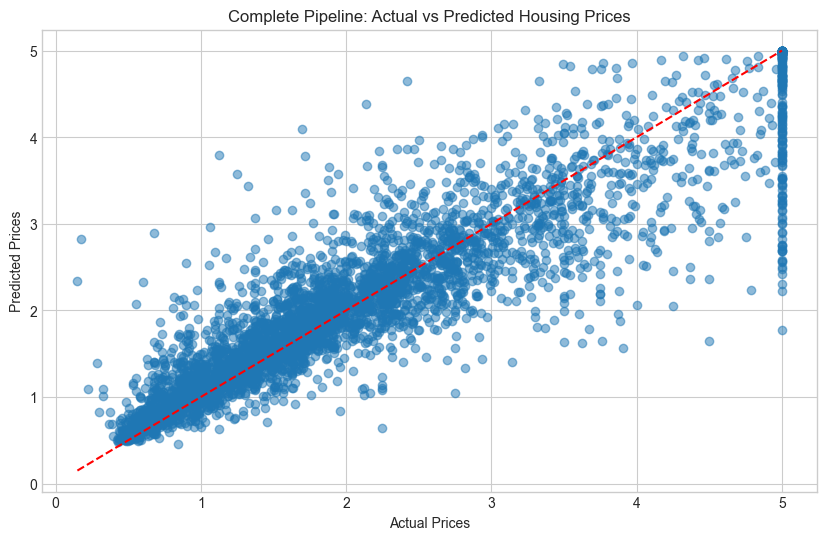


Complete housing pipeline saved to models\complete_housing_pipeline.joblib


In [19]:
# ---- Complete Housing Price Prediction Pipeline ----
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import TransformedTargetRegressor

# Step 1: Define preprocessing steps with feature engineering
housing_features = housing_df.drop('PRICE', axis=1)
housing_target = housing_df['PRICE']

# Step 2: Create a preprocessing pipeline with feature engineering
housing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('feature_engineering', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=30,
        min_samples_split=5,
        random_state=42
    ))
])

# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    housing_features, housing_target, test_size=0.2, random_state=42
)

# Step 4: Fit the pipeline
print("Fitting housing price prediction pipeline...")
housing_pipeline.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = housing_pipeline.predict(X_test)

# Step 6: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nHousing Price Prediction Results:")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Step 7: Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Complete Pipeline: Actual vs Predicted Housing Prices')
plt.show()

# Save the complete pipeline
complete_housing_pipeline_path = os.path.join(model_dir, "complete_housing_pipeline.joblib")
joblib.dump(housing_pipeline, complete_housing_pipeline_path)

print(f"\nComplete housing pipeline saved to {complete_housing_pipeline_path}")

## 8. End-to-End Project: Customer Churn Prediction

Finally, let's build a complete pipeline for our customer churn prediction task.

Fitting customer churn prediction pipeline...

Customer Churn Prediction Results:
Accuracy: 0.9474
Precision: 0.9583
Recall: 0.9583
F1 Score: 0.9583
AUC: 0.9901


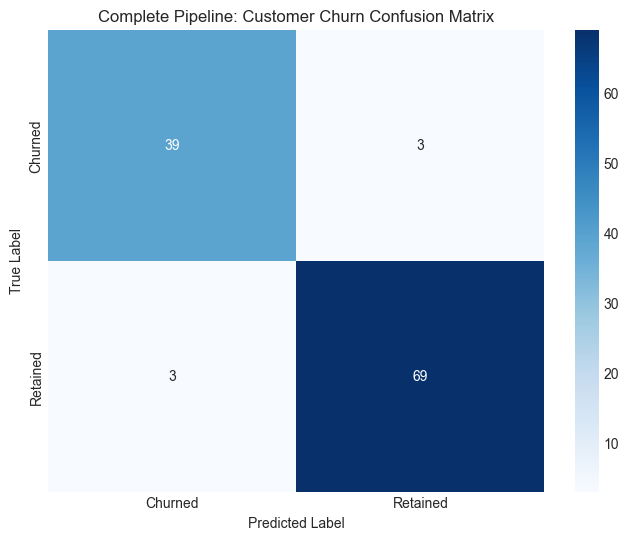

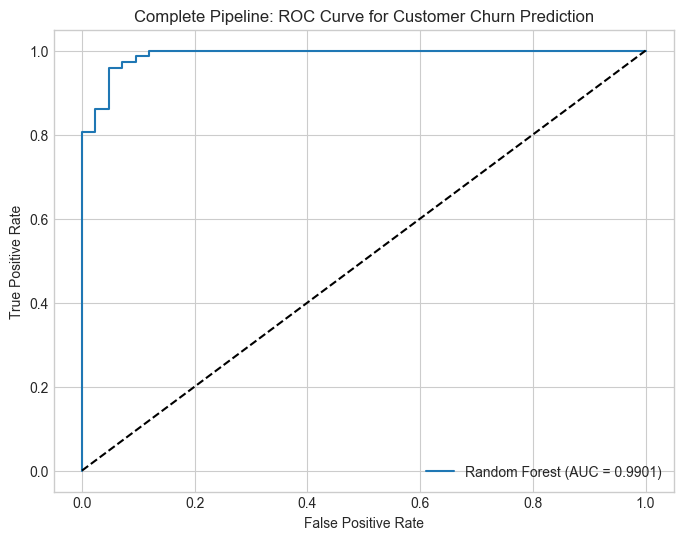


Complete customer pipeline saved to models\complete_customer_pipeline.joblib


In [20]:
# ---- Complete Customer Churn Prediction Pipeline ----
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Step 1: Define preprocessing steps
customer_features = customer_df.drop('CHURN', axis=1)
customer_target = customer_df['CHURN']

# Step 2: Create a preprocessing pipeline with feature selection
customer_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('feature_selection', SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    ))
])

# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    customer_features, customer_target, test_size=0.2, random_state=42, stratify=customer_target
)

# Step 4: Fit the pipeline
print("Fitting customer churn prediction pipeline...")
customer_pipeline.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = customer_pipeline.predict(X_test)
y_prob = customer_pipeline.predict_proba(X_test)[:, 1]

# Step 6: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\nCustomer Churn Prediction Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Step 7: Visualize results
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Churned', 'Retained'], 
            yticklabels=['Churned', 'Retained'])
plt.title('Complete Pipeline: Customer Churn Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Complete Pipeline: ROC Curve for Customer Churn Prediction')
plt.legend()
plt.show()

# Save the complete pipeline
complete_customer_pipeline_path = os.path.join(model_dir, "complete_customer_pipeline.joblib")
joblib.dump(customer_pipeline, complete_customer_pipeline_path)

print(f"\nComplete customer pipeline saved to {complete_customer_pipeline_path}")

## 9. Conclusion and Next Steps

In this notebook, we covered the essential steps for building end-to-end machine learning projects:

1. **Data acquisition and exploration** - Loading data, performing EDA, and visualizing key patterns
2. **Data preprocessing** - Handling missing values, scaling features, and feature engineering
3. **Model selection and training** - Trying different algorithms and tuning hyperparameters
4. **Model evaluation** - Using appropriate metrics and visualization techniques
5. **Model deployment** - Saving models and creating prediction functions
6. **Complete pipelines** - Building robust, reusable ML pipelines

### Next steps to explore:
- Experiment with more advanced algorithms (XGBoost, LightGBM)
- Try deep learning approaches for complex problems
- Improve feature engineering with domain knowledge
- Implement more robust model validation techniques
- Create a web API for model serving
- Monitor model performance over time
- Handle concept drift with model retraining strategies

These fundamental skills provide a strong foundation for tackling a wide range of machine learning problems in real-world scenarios.